In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision
import torchvision.datasets
from torch.utils.data import DataLoader

In [2]:
class UpscalerNetwork(nn.Module):
    def __init__(self):
        super(UpscalerNetwork, self).__init__()
        self.upsample = nn.Sequential(
            # First layer to increase feature depth while keeping the input size
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            
            # Upsampling layers to increase resolution to 224x224
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),  # 32 -> 64
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),  # 64 -> 128
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=1.75, mode='bilinear', align_corners=True),  # 128 -> 224
            nn.Conv2d(128, 3, kernel_size=3, padding=1),  # Output 3 channels (RGB)
            nn.Tanh()  # To normalize outputs to [-1, 1]
        )

    def forward(self, x):
        return self.upsample(x)

# Instantiate the model
upscaler = UpscalerNetwork()

In [3]:
# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Prepare CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(root='../data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


Files already downloaded and verified


In [4]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(upscaler.parameters(), lr=0.001)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot(target, actual):
    fig, axs = plt.subplots(1, 2)
    axs[0].imshow(np.transpose(target.numpy().clip(0, 1), (1, 2, 0)))
    axs[0].set_title('Target')
    axs[0].axis('off')
    axs[1].imshow(np.transpose(actual.detach().numpy().clip(0, 1), (1, 2, 0)))
    axs[1].set_title('Actual')
    axs[1].axis('off')
    plt.show()

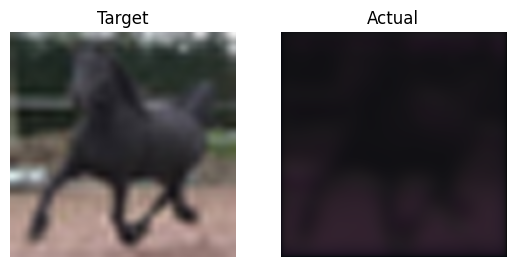

In [8]:
num_epochs = 10  # Adjust as needed

for epoch in range(num_epochs):
    for images, _ in train_loader:
        # Resize images to 224x224 for the "pseudo-ground truth"
        high_res_targets = nn.functional.interpolate(images, size=(224, 224), mode='bicubic')
        # Pass 32x32 images through the upscaler
        upscaled_images = upscaler(images)
        plot(high_res_targets[0], upscaled_images[0])
        # Compute the loss
        loss = criterion(upscaled_images, high_res_targets)
        
        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        break
    break

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
